# Lecture: REINFORCE / Actor-Critic for the Pendulum Environment

The **Pendulum** environment from Gymnasium is a classic continuous control problem where the goal is to swing up and balance an inverted pendulum by applying continuous torque. The agent must learn to apply minimal force to keep the pendulum upright and stable, while minimizing unnecessary movement and energy usage.

<img src="images/pendulum.gif" alt="Pendulum balancing" width="400"/>

## Environment Overview

- **Goal:** Keep the pendulum upright (angle = 0) using torque.
- **Observation space:** 3 continuous values
  - Cosine of the pendulum angle
  - Sine of the pendulum angle
  - Angular velocity
- **Action space:** Continuous, 1D torque value ∈ [-2.0, 2.0]
- **Reward:**
  - The reward at each timestep is:
    $$ r = -(\theta^2 + 0.1 \cdot \dot{\theta}^2 + 0.001 \cdot \tau^2) $$
    Where:
    - $\theta$ is the angle from the upright position (0 radians),
    - $\dot{\theta}$ is the angular velocity,
    - $\tau$ is the torque applied.
- **Episode termination:**
  - After a fixed number of steps (default: 200 timesteps)
  - There is **no early termination**; the task is episodic.

### Task 1

Instantiate the environment and check the state and action space wrt type and dimensions. What is the meaning of the shown arrays?

In [1]:
import gymnasium as gym

env = gym.make('Pendulum-v1')

print(env.observation_space)
print(env.action_space)

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Box(-2.0, 2.0, (1,), float32)


### Task 2

Check the environment by sampling action from action space. How good is a random agent averaged over 100 episodes?

In [2]:
import numpy as np

env = gym.make('Pendulum-v1')

n_eps = 100
reward_sum = []

for i in range(n_eps):
    obs, _ = env.reset()
    reward_per_episode = 0

    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        reward_per_episode += reward

        if terminated or truncated:
            reward_sum.append(reward_per_episode)
            break

        #env.render()

print("Mittelwert des Random Agenten: ", np.mean(reward_sum))
env.close()

Mittelwert des Random Agenten:  -1230.8187143781806


In [7]:
config = {
    'EPISODES': 500,
    'MAX_TIMESTEPS': 200,
    'BATCH_SIZE': 64,
    'DISCOUNT': 0.95,
    'LEARNING_RATE': 0.0005,
    'HIDDEN_DIM': 64,
    'LOGS': 'logs/A2C_run4/'
}

In [8]:
import gymnasium as gym
from AdvActorCriticAgent import A2CAgent

env = gym.make('Pendulum-v1')

agent = A2CAgent(env, config)
agent.train()

Episode 0, Reward: -1188.70, Average(100): -1188.70
Episode 50, Reward: -1476.07, Average(100): -1250.58
Episode 100, Reward: -1052.64, Average(100): -1235.82
Episode 150, Reward: -1187.56, Average(100): -1220.45
Episode 200, Reward: -1085.36, Average(100): -1218.95
Episode 250, Reward: -974.02, Average(100): -1223.83
Episode 300, Reward: -986.18, Average(100): -1197.91
Episode 350, Reward: -1179.35, Average(100): -1221.56
Episode 400, Reward: -1447.31, Average(100): -1287.26
Episode 450, Reward: -928.97, Average(100): -1249.31


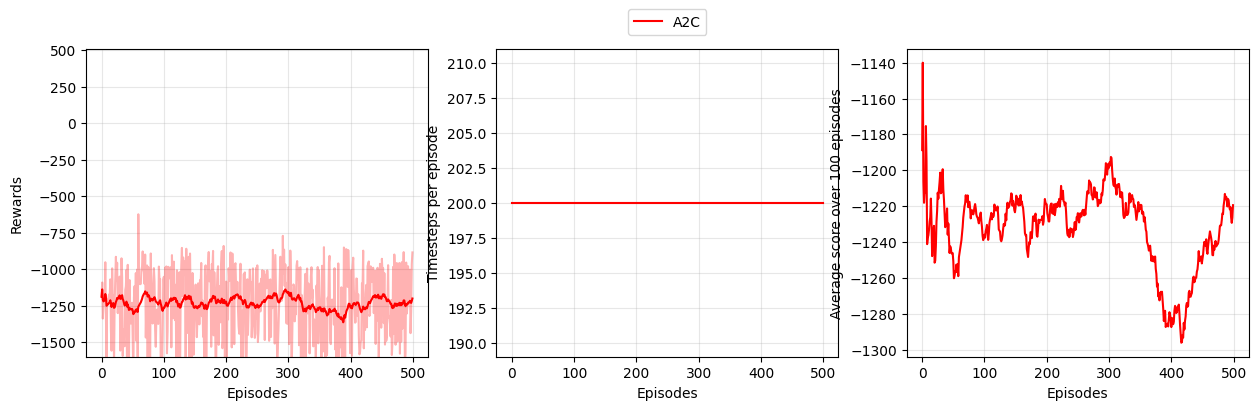

In [9]:
import pandas as pd
from AdvActorCriticAgent import plot_trainingsinformation

data_MCPG_1 = pd.read_csv(r'logs/A2C_run4/results.csv')
plot_trainingsinformation([data_MCPG_1], ['A2C'], ['red'], ylim = 510,);